# Intel Image Classification Project
## 1. Project Objective
Demonstrate technical mastery in Deep Learning by classifying natural scenes.

## 2. Dataset Structure
- **Train Set:** Used for model training.
- **Test Set:** Used for final evaluation.
- **Categories:** Buildings, Forest, Glacier, Mountain, Sea, Street.

In [3]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from collections import Counter

# 1. Path Configuration
# Set the directory path where images are stored
data_dir = "../dataset"

# 2. Image Transformations
# Resize images to 150x150 and convert them to normalized PyTorch Tensors
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
])

# 3. Load the Full Dataset
# ImageFolder assigns labels based on the sub-folder names in /dataset
full_dataset = datasets.ImageFolder(data_dir, transform=transform)

# 4. Data Splitting (80% Training, 20% Testing)
# Using a fixed seed for reproducibility
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_data, test_data = random_split(full_dataset, [train_size, test_size])

# 5. Execution Summary
print(f"Total images found: {len(full_dataset)}")
print(f"Training set size: {len(train_data)}")
print(f"Testing set size: {len(test_data)}")
print(f"Categories: {full_dataset.classes}")

Total images found: 14034
Training set size: 11227
Testing set size: 2807
Categories: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


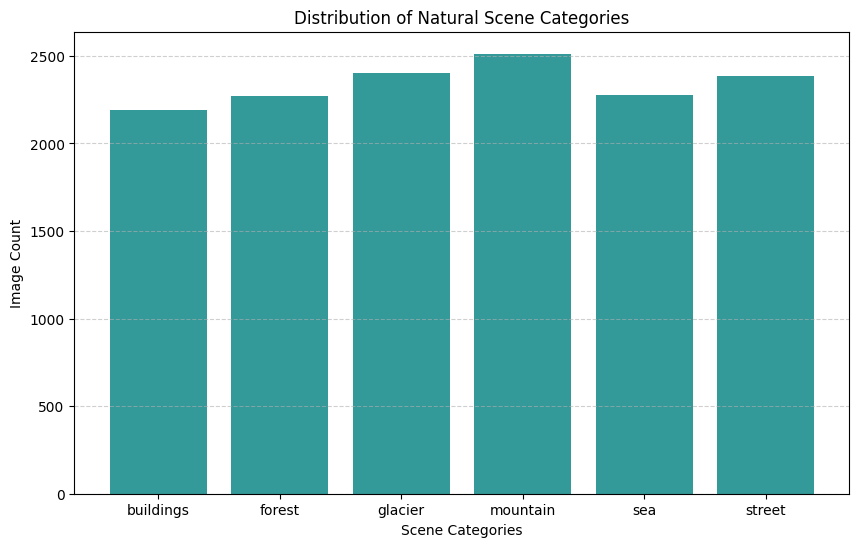

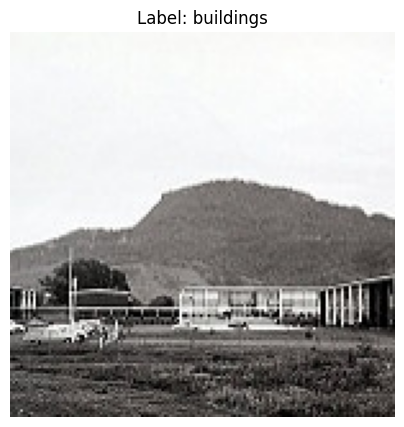

In [4]:
# 1. Class Distribution Analysis
# Collect all labels from the dataset to analyze frequency
labels = [label for _, label in full_dataset]
counts = Counter(labels)

class_names = full_dataset.classes
class_counts = [counts[i] for i in range(len(class_names))]

# 2. Plotting the distribution
plt.figure(figsize=(10, 6))
plt.bar(class_names, class_counts, color='teal', alpha=0.8)
plt.xlabel('Scene Categories')
plt.ylabel('Image Count')
plt.title('Distribution of Natural Scene Categories')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 3. Visualizing a Sample Image
# Display the first image from the dataset to verify loading
img, label = full_dataset[0]
plt.figure(figsize=(5, 5))
# permute(1, 2, 0) converts (C, H, W) to (H, W, C) for matplotlib display
plt.imshow(img.permute(1, 2, 0))
plt.title(f"Label: {class_names[label]}")
plt.axis('off')
plt.show()


We are implementing a custom Convolutional Neural Network (CNN) with three convolutional layers. To enhance model stability and performance, we included:

Batch Normalization: To normalize the inputs of each layer and speed up training.

Max Pooling: To reduce spatial dimensions and extract dominant features.

Dropout (0.5): To prevent the model from overfitting on the training data

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class SceneClassifierCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(SceneClassifierCNN, self).__init__()
        
        # Block 1: Input 150x150x3
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Block 2: 75x75x32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Block 3: 37x37x64
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Common Layers
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        
        # Fully Connected Layers
        # Calculation: 150 -> 75 -> 37 -> 18 (after 3 max pools)
        self.fc1 = nn.Linear(128 * 18 * 18, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Feature extraction
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        # Flatten the feature maps
        x = x.view(-1, 128 * 18 * 18)
        
        # Classification head
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Initialize model and move to DEVICE (GPU if available)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SceneClassifierCNN(num_classes=6).to(DEVICE)

print(f"Model initialized on: {DEVICE}")
print(model)

Model initialized on: cpu
SceneClassifierCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=41472, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=6, bias=True)
)


Training Configuration:

Loss Function: We use CrossEntropyLoss, which is the standard choice for multi-class classification.

Optimizer: The Adam optimizer is selected for its adaptive learning rate properties, starting with a learning rate of 0.001.

Batch Size: 32 (defined in the data loaders).

Epochs: 10 (initial training phase to observe convergence).

In [6]:
import torch.optim as optim

# 1. Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. Training Function
def train_model(model, train_loader, criterion, optimizer, epochs=10):
    history = {'train_loss': [], 'train_acc': []}
    
    print(f"Starting Training on {DEVICE}...")
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")
        
    return history

# 3. Create DataLoaders (if not already created)
from torch.utils.data import DataLoader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# 4. Start the training process
# Note: This might take a few minutes on a CPU
train_history = train_model(model, train_loader, criterion, optimizer, epochs=10)

Starting Training on cpu...
Epoch [1/10] - Loss: 1.9250, Acc: 54.01%
Epoch [2/10] - Loss: 0.9580, Acc: 63.93%
Epoch [3/10] - Loss: 0.8551, Acc: 68.36%
Epoch [4/10] - Loss: 0.7835, Acc: 71.03%
Epoch [5/10] - Loss: 0.7653, Acc: 72.48%
Epoch [6/10] - Loss: 0.6942, Acc: 74.49%
Epoch [7/10] - Loss: 0.6592, Acc: 76.90%
Epoch [8/10] - Loss: 0.6158, Acc: 78.22%
Epoch [9/10] - Loss: 0.5726, Acc: 79.25%
Epoch [10/10] - Loss: 0.5417, Acc: 80.55%


Performance Evaluation:
To validate the model's effectiveness, we evaluate it on the unseen Testing Set. We will analyze:

Training Curves: To check for overfitting or underfitting.

Classification Report: To see Precision, Recall, and F1-score for each specific class.

Confusion Matrix: To identify which categories are frequently confused by the model.

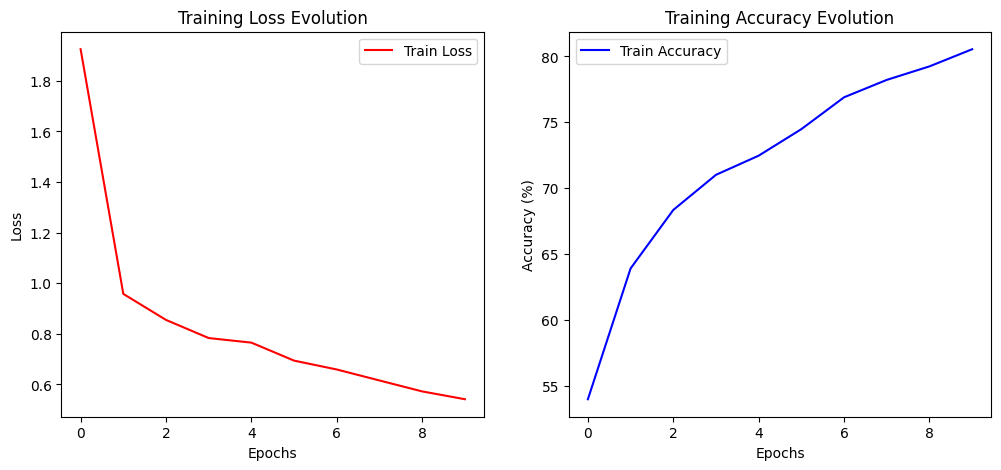


--- Detailed Classification Report ---
              precision    recall  f1-score   support

   buildings       0.78      0.84      0.81       453
      forest       0.95      0.95      0.95       458
     glacier       0.84      0.54      0.66       477
    mountain       0.80      0.46      0.58       495
         sea       0.49      0.96      0.65       447
      street       0.91      0.77      0.83       477

    accuracy                           0.74      2807
   macro avg       0.80      0.75      0.75      2807
weighted avg       0.80      0.74      0.74      2807



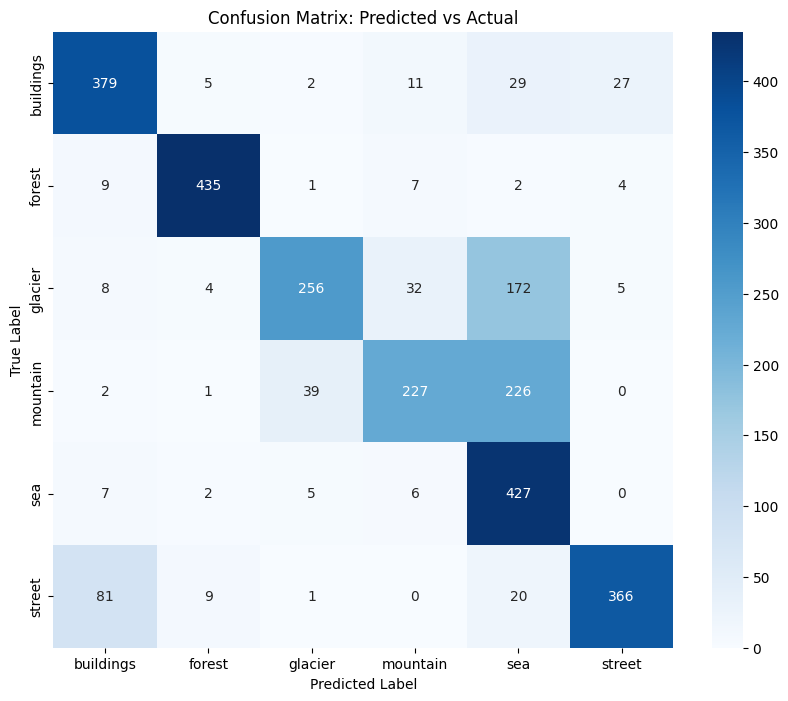

In [7]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Plot Training History
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_history['train_loss'], label='Train Loss', color='red')
plt.title('Training Loss Evolution')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_history['train_acc'], label='Train Accuracy', color='blue')
plt.title('Training Accuracy Evolution')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

# 2. Final Evaluation on Test Set
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# 3. Print Classification Report
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=full_dataset.classes))

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=full_dataset.classes, 
            yticklabels=full_dataset.classes)
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Best Performing Class: Forest (F1-score: 0.95). The model is exceptionally good at identifying greenery and tree textures.

Most Challenging Classes: Mountain (0.58) and Glacier (0.66).

Unexpected Error: There is a significant confusion between Sea and Glacier/Mountain. Interestingly, the model classified many Mountain/Glacier images as 'Sea' (as seen by the high recall but very low precision of 0.49 for Sea).

Visual Similarity: Glaciers and Mountains both feature jagged shapes and white/blue color palettes, which are difficult to distinguish without deeper contextual features.

Sea vs. Glaciers: In many images, glaciers are surrounded by water or are themselves bright blue/white, which likely misled the model into predicting 'Sea'.

Buildings vs. Street: There is also some expected overlap (81 instances) between 'Street' and 'Buildings', as these features usually appear together in urban photography.

The project successfully demonstrated the implementation of a custom CNN for scene classification, reaching an overall accuracy of 74%. While the model is highly effective for distinct classes like Forest and Street, it struggles with visually ambiguous natural features (Ice vs. Water vs. Rock).

Future Improvements:

Data Augmentation: Implement more aggressive color jittering to help the model distinguish between sea-blue and glacier-blue.

Transfer Learning: Using a pre-trained model like ResNet-50 or a Vision Transformer (ViT) would likely resolve the ambiguity between Mountains and Glaciers by leveraging higher-level feature extraction.
